In [202]:
import pandas as pd
import numpy as np


In [203]:
df=pd.read_csv(r'C:\Users\KhushiAgarwal\OneDrive - Aditi Consulting\Downloads\Admission_Predict.csv')

In [204]:
df.shape

(500, 9)

In [205]:
df.sample(3)

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
403,404,330,116,4,4.0,3.5,9.23,1,0.91
201,202,315,110,2,3.5,3.0,8.46,1,0.72
75,76,329,114,2,2.0,4.0,8.56,1,0.72


In [206]:
df.isnull().sum()

Serial No.           0
GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Chance of Admit      0
dtype: int64

In [207]:
df.drop(columns=['Serial No.'],inplace=True)

In [208]:
df.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


In [209]:
x=df.iloc[:,0:-1].values
y=df.iloc[:,-1].values

In [210]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [211]:
x=scaler.fit_transform(x)

In [212]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.1,random_state=0)

In [213]:
import tensorflow 
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [214]:
model=Sequential()

In [215]:
x_train.shape

(450, 7)

In [216]:
model.add(Dense(14,activation='relu',input_dim=x_train.shape[1]))
model.add(Dense(1,activation='linear'))

c:\Users\KhushiAgarwal\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [217]:
# I/P Layer = 7 Inputs = 21 params + 3 bias 
# Hidden Layer = 3 params + 1 bias
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_29 (Dense)                │ (None, 14)             │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 1)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 127 (508.00 B)

 Trainable params: 127 (508.00 B)

 Non-trainable params: 0 (0.00 B)

In [218]:
model.compile(optimizer='Adam',loss='mean_squared_error')

In [219]:
history=model.fit(x_train,y_train,epochs=100,batch_size=10,verbose=1,validation_split=0.2)

Epoch 1/100


36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2.2980 - val_loss: 1.6450
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.2705 - val_loss: 0.9465
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7517 - val_loss: 0.5832
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4673 - val_loss: 0.3745
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3040 - val_loss: 0.2447
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2043 - val_loss: 0.1735
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1452 - val_loss: 0.1298
Epoch 8/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1085 - val_loss: 0.1053
Epoch 9/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0858 - val_loss: 0.0886
Epoch 10/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0700 - val_loss: 0.0769
Epoch 11/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0589 - val_loss: 0.0669
Epoch 12/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0499 - val_lo

In [220]:
y_pred=model.predict(x_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


In [221]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.7320706527601737

In [222]:
# Model evaluation and Improvements
# 1.Increase the number of epochs
# 2.Increase nodes in the hidden layer
# 3.Add more layers
  

In [223]:
history.history

{'loss': [2.2980053424835205,
  1.2705061435699463,
  0.7516981363296509,
  0.46730953454971313,
  0.3039737045764923,
  0.20427735149860382,
  0.1451563537120819,
  0.10846570134162903,
  0.08576295524835587,
  0.07003691792488098,
  0.05889827385544777,
  0.04991142079234123,
  0.04362603649497032,
  0.038413893431425095,
  0.03444763645529747,
  0.031217675656080246,
  0.02863464318215847,
  0.026763472706079483,
  0.024909498170018196,
  0.02333304099738598,
  0.02191051095724106,
  0.020880185067653656,
  0.019642749801278114,
  0.01879524067044258,
  0.01790613867342472,
  0.01720656454563141,
  0.01651597209274769,
  0.015882622450590134,
  0.015441898256540298,
  0.014875606633722782,
  0.014421001076698303,
  0.013867278583347797,
  0.013550818897783756,
  0.013134494423866272,
  0.012843539007008076,
  0.012493002228438854,
  0.012193243019282818,
  0.011959634721279144,
  0.011612232774496078,
  0.011451290920376778,
  0.011068143881857395,
  0.010819963179528713,
  0.010651

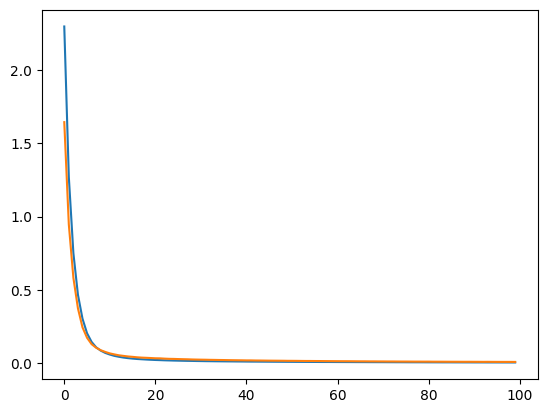

In [224]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])